# BUSINESS DATA ANALYTICS APPLIED LAB #1  
## RESTAURANT ANALYTICS - WEEK 2

**Asignatura:** Data Analytics (Código: 43390860)  
**Semana:** 2 - Perfil del analista, modelo relacional y trabajo reproducible

### Contexto de negocio

Usted ha sido contratado como **Business Data Analyst** por una cadena de restaurantes que conserva sus datos de productos, clientes y ventas en cuatro archivos independientes. La gerencia conoce cuánto vende, pero no puede comparar las dos semanas, identificar los productos que generan más ingresos ni estimar la recurrencia de sus clientes.

Su misión es consolidar las fuentes, validar las uniones y construir indicadores que apoyen decisiones sobre el menú y la fidelización. El proceso debe quedar documentado en un repositorio y resumido en un informe ejecutivo de una página.

> **Alcance del análisis.** Los archivos contienen precios de venta, pero no costos, cantidades ni descuentos. Por tanto, analice ingresos, frecuencia de compra y recurrencia; no rentabilidad, utilidad o margen.

## Organización mínima del trabajo reproducible

Antes de comenzar, organice su trabajo con una estructura sencilla:

```text
lab-restaurant/
│
├── data/
├── lab_Sem2_DA.ipynb
└── README.md
```

- `data/`: contiene los archivos CSV del laboratorio.
- `lab_Sem2_DA.ipynb`: notebook ejecutado.
- `README.md`: objetivo, datos utilizados, instrucciones de ejecución y principales hallazgos.

> **Criterio de reproducibilidad:** al finalizar, el notebook debe poder ejecutarse nuevamente desde la primera hasta la última celda sin modificar manualmente el código, salvo la carga inicial de los archivos si trabaja en Google Colab.


## 1. Conociendo las fuentes de datos

Trabajará con cuatro archivos:

1. `Restaurant-Foods.csv`: catálogo de productos y precios.
2. `Restaurant-Customers.csv`: información de clientes.
3. `Restaurant-Week1-Sales.csv`: registros de venta de la semana 1.
4. `Restaurant-Week2-Sales.csv`: registros de venta de la semana 2.

Antes de unir las tablas, identifique qué representa una fila en cada archivo y cuáles columnas permiten relacionarlas.

In [ ]:
# Paso 1: Carga de librerías y archivos
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

foods = pd.read_csv('Restaurant-Foods.csv')
customers = pd.read_csv('Restaurant-Customers.csv')
week1 = pd.read_csv('Restaurant-Week1-Sales.csv')
week2 = pd.read_csv('Restaurant-Week2-Sales.csv')

# Identificar la semana de cada registro de venta
week1['Semana'] = 1
week2['Semana'] = 2
all_sales = pd.concat([week1, week2], ignore_index=True)

In [ ]:
# Paso 2: Inspección inicial de las tablas
print('foods:', foods.shape)
print('customers:', customers.shape)
print('week1:', week1.shape)
print('week2:', week2.shape)

display(foods.head(10))
display(week1.head(3))

# Por privacidad, no se muestran nombres de clientes.
print('Columnas de customers:', list(customers.columns))

foods: (10, 3)
customers: (1000, 6)
week1: (250, 3)
week2: (250, 3)


,Food ID,Food Item,Price
0,1,Sushi,3.99
1,2,Burrito,9.99
2,3,Taco,2.99
3,4,Quesadilla,4.25
4,5,Pizza,2.49
5,6,Pasta,13.99
6,7,Steak,24.99
7,8,Salad,11.25
8,9,Donut,0.99
9,10,Drink,1.75


,Customer ID,Food ID,Semana
0,537,9,1
1,97,4,1
2,658,1,1


Columnas de customers: ['ID', 'First Name', 'Last Name', 'Gender', 'Company', 'Occupation']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Claves y relaciones

- `Food ID` identifica cada producto en `foods`.
- `ID` identifica cada cliente en `customers`.
- `Food ID` en las ventas referencia al producto comprado.
- `Customer ID` en las ventas referencia al cliente.

Por tanto:

- un producto puede aparecer en muchos registros de venta;
- un cliente puede aparecer en muchos registros de venta.

Antes de hacer un `merge`, conviene comprobar que las claves principales sean únicas y que las referencias existan.

### Esquema relacional mínimo

```text
CUSTOMERS
   ID
    │
    │ 1 : N
    ▼
  SALES
   ▲
   │ N : 1
   │
 FOODS
Food ID
```

Interpretación:

- un cliente puede aparecer en varios registros de venta;
- un producto puede aparecer en varios registros de venta;
- cada registro de venta referencia a un único cliente y a un único producto.


In [ ]:
# Paso 3: Validación de estructura, claves y referencias
assert foods['Food ID'].is_unique, 'Food ID debe ser único en foods'
assert customers['ID'].is_unique, 'ID debe ser único en customers'

assert all_sales['Food ID'].isin(foods['Food ID']).all(), \
    'Existen ventas con Food ID sin correspondencia'

assert all_sales['Customer ID'].isin(customers['ID']).all(), \
    'Existen ventas con Customer ID sin correspondencia'

print('Claves y referencias validadas correctamente.')

Claves y referencias validadas correctamente.


## 2. Consolidación de información

La tabla de ventas contiene identificadores. Para interpretarlos, debemos relacionarlos con los catálogos de productos y clientes.

El parámetro `validate='many_to_one'` permite comprobar que cada identificador de venta corresponda a un único registro en la tabla de referencia.

### Antes de ejecutar la unión: haga una predicción

Sin ejecutar todavía el siguiente bloque, responda:

> **¿Cuántas filas espera encontrar en `full_report` después de realizar las dos uniones? ¿Por qué?**

Escriba su respuesta en la siguiente celda.


**Mi predicción:**  

- Número esperado de filas: 9-10
- Justificación:
Tuvimos en cuenta las tablas de customers y food, es posible que quede este numero de filas aprox.


In [ ]:
# Paso 4: Consolidación de información
full_report = (
    all_sales
    .merge(
        foods,
        on='Food ID',
        how='left',
        validate='many_to_one'
    )
    .merge(
        customers,
        left_on='Customer ID',
        right_on='ID',
        how='left',
        validate='many_to_one'
    )
)

# La unión no debería crear ni eliminar registros de venta
print('Registros antes de unir:', len(all_sales))
print('Registros después de unir:', len(full_report))

assert len(full_report) == len(all_sales), \
    'La unión modificó inesperadamente el número de registros'

# Comprobar que las uniones no dejaron datos esenciales vacíos
assert full_report['Price'].notna().all(), \
    'Existen ventas sin precio asociado'

assert full_report['Occupation'].notna().all(), \
    'Existen ventas sin ocupación asociada'

print('Consolidación validada.')
print('full_report:', full_report.shape)
display(full_report.head())

Registros antes de unir: 500
Registros después de unir: 500
Consolidación validada.
full_report: (500, 11)


,Customer ID,Food ID,Semana,Food Item,Price,ID,First Name,Last Name,Gender,Company,Occupation
0,537,9,1,Donut,0.99,537,Cheryl,Carroll,Female,Zoombeat,Registered Nurse
1,97,4,1,Quesadilla,4.25,97,Amanda,Watkins,Female,Ozu,Account Coordinator
2,658,1,1,Sushi,3.99,658,Patrick,Webb,Male,Browsebug,Community Outreach Specialist
3,202,2,1,Burrito,9.99,202,Louis,Campbell,Male,Rhynoodle,Account Representative III
4,155,9,1,Donut,0.99,155,Carolyn,Diaz,Female,Gigazoom,Database Administrator III


## 3. Construcción de indicadores comerciales

En este conjunto de datos, cada fila corresponde a un **registro de venta**. Como no existe una columna de cantidad, contar filas permite analizar **frecuencia de compra**, pero no unidades vendidas.

Construiremos indicadores de:

- ingresos registrados;
- número de registros de venta;
- ingreso promedio por registro;
- frecuencia de compra por producto;
- recurrencia de clientes;
- ingresos agregados por ocupación.

In [ ]:
# Paso 5: Construcción de indicadores (KPIs)
full_report['Ingresos'] = full_report['Price']

total_revenue = full_report['Ingresos'].sum()

weekly_summary = (
    full_report
    .groupby('Semana')
    .agg(
        Registros_Venta=('Customer ID', 'count'),
        Ingresos=('Ingresos', 'sum'),
        Ingreso_Promedio=('Ingresos', 'mean')
    )
)

top_foods = (
    full_report
    .groupby('Food Item')
    .agg(
        Frecuencia_Compra=('Customer ID', 'count'),
        Ingresos_Totales=('Ingresos', 'sum')
    )
    .sort_values('Ingresos_Totales', ascending=False)
)

print('Ingresos totales:', total_revenue)
display(weekly_summary)
display(top_foods.head(10))

Ingresos totales: 3886.56


,Registros_Venta,Ingresos,Ingreso_Promedio
Semana,,,
1,250,1962.68,7.85072
2,250,1923.88,7.69552


,Frecuencia_Compra,Ingresos_Totales
Food Item,,
Steak,50,1249.50
Pasta,54,755.46
Burrito,57,569.43
Salad,48,540.00
Quesadilla,49,208.25
Sushi,43,171.57
Taco,46,137.54
Drink,59,103.25
Pizza,39,97.11


### Lectura de resultados antes de graficar

Observe la tabla `top_foods` y responda:

1. ¿Cuál es el producto con mayor **frecuencia de compra**?
2. ¿Cuál es el producto con mayores **ingresos**?
3. ¿Coinciden ambos productos?
4. Si no coinciden, ¿qué interpretación comercial preliminar haría?

> No avance al gráfico hasta haber respondido estas preguntas.


**Respuesta:**  

1.  "Drink"
2.  "Steak"
3.  Parcialmente
4.  Cercanos a la frecuencia de compra, pero alejado a los ingresos generados


In [ ]:
# Paso 6: Recurrencia de clientes
customers_w1 = set(week1['Customer ID'])
customers_w2 = set(week2['Customer ID'])

returning_customers = customers_w1.intersection(customers_w2)

# De los clientes observados en la semana 1,
# ¿qué porcentaje volvió a aparecer en la semana 2?
recurrence_rate = (
    len(returning_customers)
    / week1['Customer ID'].nunique()
    * 100
)

print('Clientes únicos semana 1:', week1['Customer ID'].nunique())
print('Clientes únicos semana 2:', week2['Customer ID'].nunique())
print('Clientes recurrentes:', len(returning_customers))
print(f'Tasa de recurrencia: {recurrence_rate:.1f}%')

Clientes únicos semana 1: 221
Clientes únicos semana 2: 224
Clientes recurrentes: 46
Tasa de recurrencia: 20.8%


In [ ]:
# Paso 7: Ingresos acumulados por ocupación (análisis agregado)
occupation_spend = (
    full_report
    .groupby('Occupation')['Ingresos']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

display(occupation_spend.to_frame('Ingresos'))

,Ingresos
Occupation,
Compensation Analyst,116.68
Sales Representative,104.18
Marketing Manager,99.40
Cost Accountant,80.21
Assistant Media Planner,72.69


## 4. La misma pregunta con SQL

Hasta este punto utilizó Pandas. Ahora obtenga el resumen semanal mediante SQL y compare los resultados.

El objetivo no es aprender dos soluciones diferentes de memoria, sino reconocer que **Pandas y SQL pueden responder la misma pregunta analítica**.

In [ ]:
# Paso 8: Cargar la tabla consolidada en una base SQLite temporal
connection = sqlite3.connect(':memory:')
full_report.to_sql(
    'ventas',
    connection,
    if_exists='replace',
    index=False
)

query = '''
SELECT
    Semana,
    COUNT(*) AS Registros_Venta,
    SUM(Price) AS Ingresos,
    AVG(Price) AS Ingreso_Promedio
FROM ventas
GROUP BY Semana
ORDER BY Semana;
'''

weekly_summary_sql = pd.read_sql_query(query, connection)

print('Resumen con Pandas')
display(weekly_summary.reset_index())

print('Resumen con SQL')
display(weekly_summary_sql)

Resumen con Pandas


,Semana,Registros_Venta,Ingresos,Ingreso_Promedio
0,1,250,1962.68,7.85072
1,2,250,1923.88,7.69552


Resumen con SQL


,Semana,Registros_Venta,Ingresos,Ingreso_Promedio
0,1,250,1962.68,7.85072
1,2,250,1923.88,7.69552


### Intervención mínima en SQL

La consulta anterior ordena las semanas cronológicamente. Ahora modifíquela para que los resultados queden ordenados de **mayor a menor ingreso**.

Cambie únicamente la cláusula `ORDER BY` y ejecute nuevamente la consulta.


In [ ]:
# TODO: modifique únicamente ORDER BY para ordenar de mayor a menor ingreso
query_ingresos = '''
SELECT
    Semana,
    COUNT(*) AS Registros_Venta,
    SUM(Price) AS Ingresos,
    AVG(Price) AS Ingreso_Promedio
FROM ventas
GROUP BY Semana
ORDER BY Ingresos DESC;
'''
# SOLUCION: Usar parametro de ingreso con DESC
weekly_summary_sql_ordenado = pd.read_sql_query(
    query_ingresos,
    connection
)

display(weekly_summary_sql_ordenado)


,Semana,Registros_Venta,Ingresos,Ingreso_Promedio
0,1,250,1962.68,7.85072
1,2,250,1923.88,7.69552


### Pregunta de control

Compare las dos tablas anteriores:

> ¿Los resultados obtenidos con Pandas y SQL son consistentes? Si encuentra una diferencia, revise el código antes de continuar.

RTA // SI, Ambos son consistentes

## 5. Visualización para el informe ejecutivo

Primero compare **frecuencia de compra** e **ingresos por producto**. Son indicadores relacionados, pero no equivalentes: un producto puede aparecer muchas veces y no ser el que más ingresos genera.

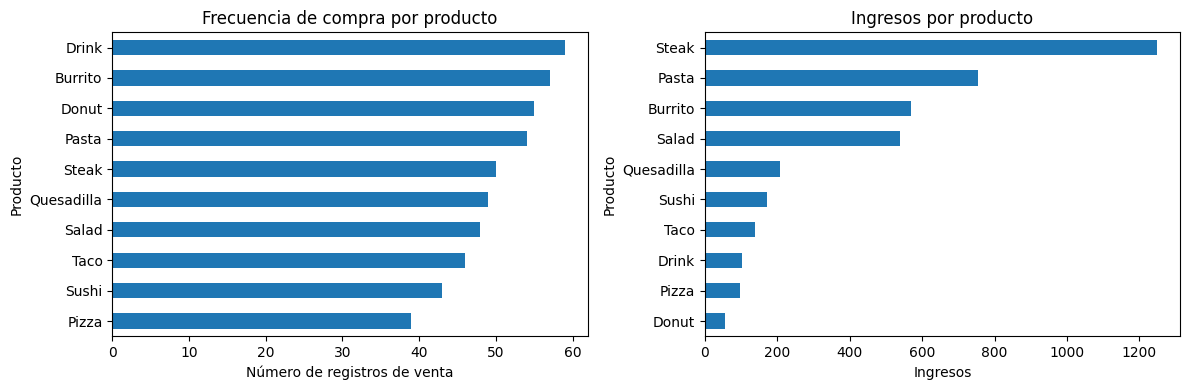

In [ ]:
# Paso 9: Desempeño del menú
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top_foods.sort_values('Frecuencia_Compra').plot(
    kind='barh',
    y='Frecuencia_Compra',
    ax=axes[0],
    legend=False,
    title='Frecuencia de compra por producto'
)
axes[0].set_xlabel('Número de registros de venta')
axes[0].set_ylabel('Producto')

top_foods.sort_values('Ingresos_Totales').plot(
    kind='barh',
    y='Ingresos_Totales',
    ax=axes[1],
    legend=False,
    title='Ingresos por producto'
)
axes[1].set_xlabel('Ingresos')
axes[1].set_ylabel('Producto')

plt.tight_layout()
plt.show()

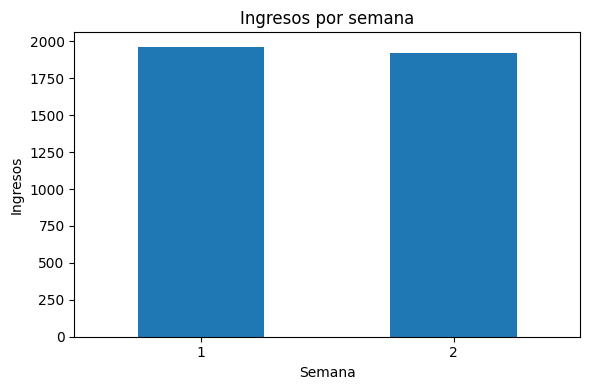

In [ ]:
# Paso 10: Comparación semanal de ingresos
weekly_summary['Ingresos'].plot(
    kind='bar',
    figsize=(6, 4),
    title='Ingresos por semana'
)

plt.xlabel('Semana')
plt.ylabel('Ingresos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Exploración autónoma: una visualización adicional

Hasta este punto ha utilizado dos visualizaciones proporcionadas en el notebook. Ahora debe producir **una tercera visualización** que considere útil para apoyar una recomendación del informe ejecutivo.

Puede explorar, por ejemplo:

- recurrencia de clientes;
- ingresos por ocupación;
- registros de venta por semana;
- ingreso promedio por registro;
- comparación entre dos indicadores del menú.

### Requisitos

1. Utilice `matplotlib` o las funciones de gráfico de `pandas`.
2. Incluya título y etiquetas claras.
3. No muestre nombres de clientes.
4. Debajo del gráfico escriba **una frase** que explique por qué esa visualización aporta a una decisión del negocio.


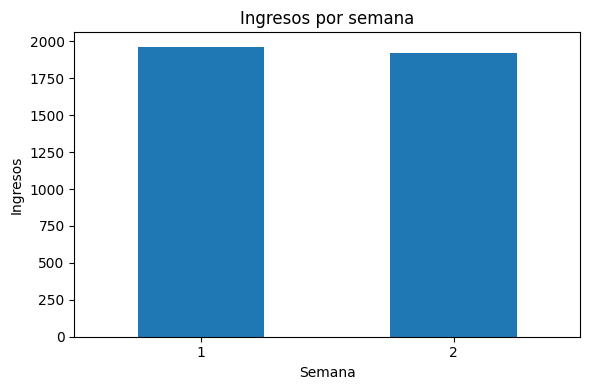

In [ ]:
# TODO: construya aquí una tercera visualización de su elección

# Ejemplo de estructura:
# datos_para_grafico = ...
# datos_para_grafico.plot(...)
# plt.title('...')
# plt.xlabel('...')
# plt.ylabel('...')
# plt.tight_layout()
# plt.show()



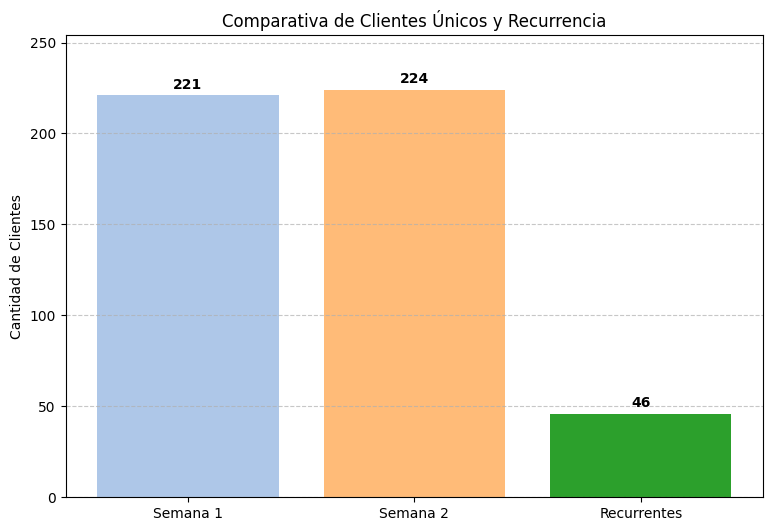

In [ ]:
import matplotlib.pyplot as plt

# Obtener los IDs únicos por semana
set_w1 = set(week1['Customer ID'])
set_w2 = set(week2['Customer ID'])
recurrentes = len(set_w1.intersection(set_w2))

# Datos para el gráfico
categorias = ['Semana 1', 'Semana 2', 'Recurrentes']
valores = [len(set_w1), len(set_w2), recurrentes]
colores = ['#aec7e8', '#ffbb78', '#2ca02c']

plt.figure(figsize=(9, 6))
barras = plt.bar(categorias, valores, color=colores)

# Añadir etiquetas de datos
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 2, yval, ha='center', va='bottom', fontweight='bold')

plt.title('Comparativa de Clientes Únicos y Recurrencia')
plt.ylabel('Cantidad de Clientes')
plt.ylim(0, max(valores) + 30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**¿Por qué esta visualización es útil para la toma de decisiones?**

Esta visualización permite evaluar rápidamente la fidelidad de los clientes, indicando la efectividad de las estrategias de retención entre semanas.

## 7. Análisis

Responda brevemente en una celda de texto antes de elaborar el informe ejecutivo:

1. ¿El producto con mayor frecuencia de compra es también el de mayores ingresos?
2. ¿Qué cambió entre las semanas en ingresos, registros de venta e ingreso promedio por registro?
3. ¿Qué porcentaje de los clientes de la semana 1 volvió a aparecer en la semana 2?
4. ¿Qué ocupaciones concentran más ingresos en los datos observados?
5. ¿Qué información adicional necesitaría para explicar las diferencias encontradas?

> **Importante:** describa asociaciones y diferencias observadas. Con estos datos no puede demostrar causalidad.

### Escriba aquí su análisis

**1. Desempeño del menú:** No, el producto mas vendido "Drink" no es el que reporta mayores ingresos, este seria "steak".

**2. Comparación semanal:**  Los clientes de la semana 2 fueron mayores, pero reportaron un ingreso y promedio por registro inferior al de la semana 1.

**3. Recurrencia:**  20% aprox (46 clientes).

**4. Perfil agregado:**  El analista de compensasion y el representante de ventas reportaron ingresos de mas de 100 c/u.

**5. Limitaciones de los datos:** Costos de producción, recurrencia de semanas anteriores, ingresos netos.

## 8. Conclusiones y recomendación

Redacte entre 3 y 5 conclusiones sustentadas en las cifras y gráficos obtenidos. Después formule una acción prioritaria para la siguiente semana de operación.

Evite:

- afirmar rentabilidad, utilidad o margen;
- atribuir causalidad a una variación de solo dos semanas;
- hacer afirmaciones sobre clientes individuales a partir de variables como ocupación o género.

- 1) Pudimos observar a partir de las graficas y tablas que el producto mas vendido no es el que genera mayor ganancia, sin tener en cuenta los costos de produccion.
- 2) El restaurante esta localizado en un area cercana a empresas donde sus empleados de mayor concurrencia sean del area de ventas y analisis.
- 3) Dado que en cada semana se registraron 250 ventas, la variedas de los precios representa un menor ingreso promedio por venta en la semana 2.
- 4) La baja retención del 20.8% muestra un consumo mayoritariamente ocasional, evidenciando la necesidad de fidelizar a los clientes de las empresas cercanas.

## 9. Evidencia del laboratorio

Para la entrega del laboratorio:

1. conserve este notebook ejecutado;
2. incluya el notebook y un `README.md` en su repositorio;
3. el README debe indicar objetivo, archivos utilizados, instrucciones y hallazgos;
4. no publique nombres de clientes ni el archivo de clientes en un repositorio público;
5. elabore el *One-Page Executive Report* de acuerdo con la guía del laboratorio.